In [207]:
import numpy as np
import sys
import pandas as pd
import time

In [208]:
%load_ext autoreload
%autoreload 2

sys.path.append("../src") 
import visualization as visual
import data_splitting as split
import preprocessing as prep
import neural_network as MLP
import metrics as metricas
import utils as utils
import stage_grid_search as sgs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [209]:
# cargo los datasets
X_images = np.load("../data/X_images.npy")
y_images = np.load("../data/y_images.npy")

<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
1) Análisis y Preprocesamiento de Datos
</h1>

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
1.a) Examinar el dataset
</h3>

In [210]:
# Dimensiones y tipos
print("Shape X:", X_images.shape)
print("Shape y:", y_images.shape)

print("Tipo X:", X_images.dtype)
print("Tipo y:", y_images.dtype)

Shape X: (809555, 28, 28)
Shape y: (809555,)
Tipo X: uint8
Tipo y: uint8


El conjunto de imágenes `X_images` posee dimensión `(809555, 28, 28)`, lo que indica que el dataset contiene 809555 imágenes de tamaño 28×28 píxeles. Por otro lado, el vector de etiquetas `y_images` tiene dimensión `(809555,)`, indicando que existe una etiqueta asociada a cada imagen del dataset

In [211]:
# Cantidad de clases
clases_unicas = np.unique(y_images)

print("Cantidad de clases:", len(clases_unicas))
print("Clases:", clases_unicas)

Cantidad de clases: 47
Clases: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46]


Luego se analizaron las etiquetas presentes en el dataset utilizando `np.unique()`, con el objetivo de identificar la cantidad de clases distintas. Se verificó que el dataset contiene 47 clases diferentes, numeradas desde 0 hasta 46, coincidiendo con lo especificado en la consigna para el conjunto EMNIST Bymerge. Cada número representa una categoría distinta correspondiente a caracteres manuscritos (letras o dígitos)

In [212]:
# Rango de valores de pixeles
print("Valor mínimo:", X_images.min())
print("Valor máximo:", X_images.max())

Valor mínimo: 0
Valor máximo: 255


También se examinó el rango de valores de los píxeles presentes en las imágenes. Se observó que los valores varían entre 0 y 255, lo cual es consistente con imágenes en escala de grises representadas con 8 bits por píxel. El valor 0 corresponde a píxeles negros, mientras que el valor 255 representa píxeles blancos

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Visualizar imágenes
</div>

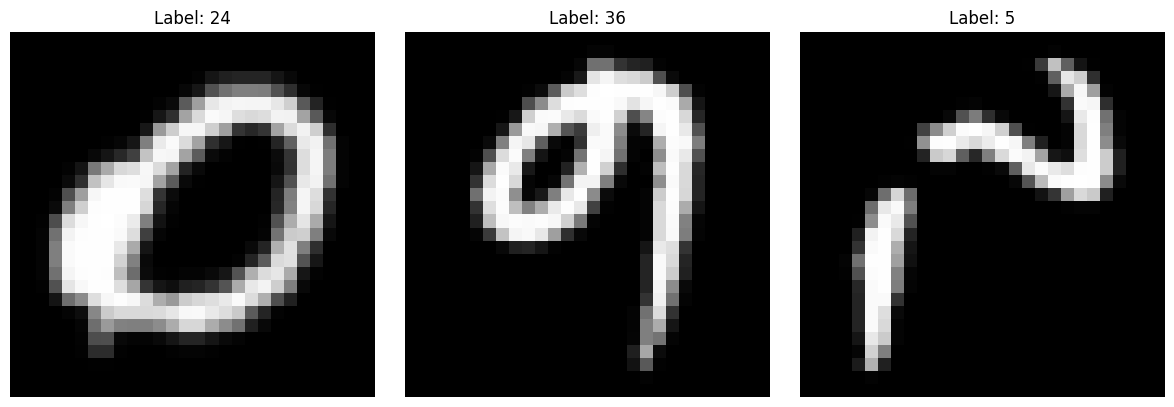

In [213]:
visual.visualizar_imagenes(X_images, y_images, cantidad=3)

Se visualizaron tres imágenes del dataset junto con sus etiquetas correspondientes. Para poder graficarlas, cada imagen fue convertida a una matriz de 28×28 píxeles mediante `reshape(28,28)`. Esto permite recuperar la forma original de la imagen, ya que cada observación representa un carácter manuscrito. Sobre cada imagen se indica su etiqueta numérica, que representa la clase a la que pertenece dentro de las 47 clases posibles del dataset.

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
1.b) Data Splitting
</h3>

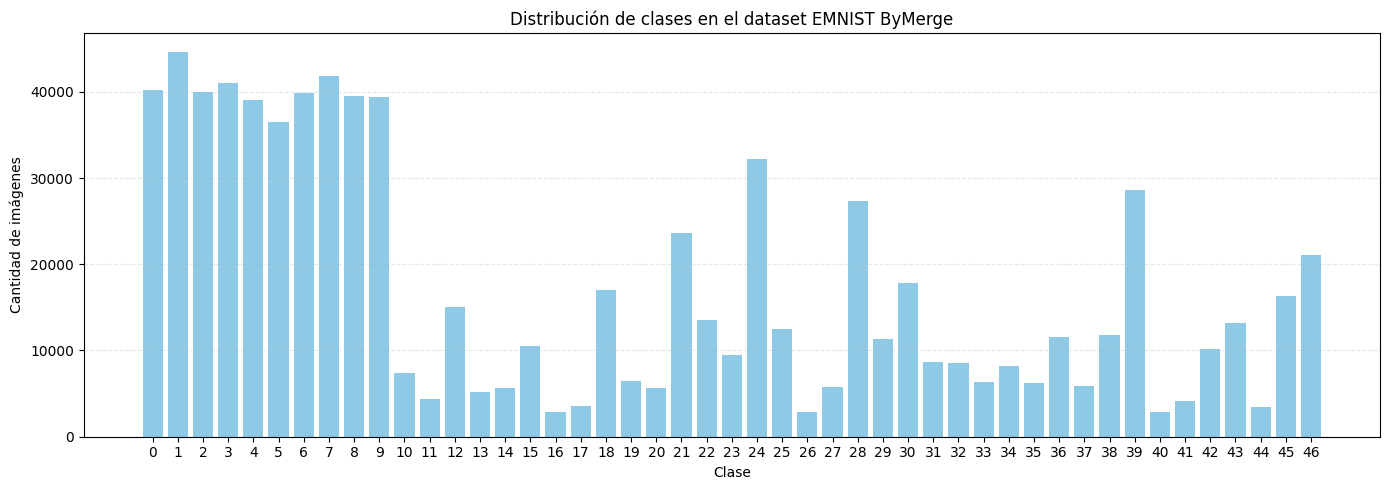

In [214]:
visual.graficar_distribucion_clases(y_images)

Del gráfico se observa que el dataset no está balanceado, ya que algunas clases poseen una cantidad significativamente mayor de ejemplos que otras. Por ejemplo, ciertas clases superan las 40.000 imágenes, mientras que otras apenas contienen unos pocos miles de muestras.

Debido a este desbalance, no resulta conveniente realizar una división completamente aleatoria de los datos, ya que algunas clases minoritarias podrían quedar subrepresentadas en los conjuntos de entrenamiento, validación o test.

Por este motivo, se utiliza *stratified sampling* durante el proceso de *data splitting*. Esta técnica realiza la división manteniendo aproximadamente la misma proporción de ejemplos de cada clase en todos los subconjuntos. De esta manera, train, validation y test conservan una distribución de clases similar a la del dataset original, permitiendo entrenar y evaluar el modelo de manera más representativa y estable

In [215]:
X_tr, X_val, X_test, y_tr, y_val, y_test = split.split_train_val_test(
    X_images,
    y_images,
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    random_state=42
)

Se dividió el dataset en tres subconjuntos: Train, Validation y Test, utilizando una proporción 70/15/15.

El 70% de los datos se asignó al conjunto de entrenamiento, utilizado para ajustar los pesos de la red neuronal durante el aprendizaje. Luego, se reservó un 15% para validación, con el objetivo de comparar configuraciones del modelo y tomar decisiones durante el desarrollo. El 15% restante se dejó como conjunto de test, separado del entrenamiento, para evaluar de manera final la performance sobre datos no vistos.

Esta proporción permite destinar la mayor parte de los ejemplos al entrenamiento, sin perder conjuntos independientes para validar y testear el modelo

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
1.c) Normalización
</h3>

In [216]:
X_tr = prep.normalizar_imagenes(X_tr)
X_val = prep.normalizar_imagenes(X_val)
X_test = prep.normalizar_imagenes(X_test)

Se normalizaron las imágenes dividiendo todos los valores de píxel por 255. De esta manera, los datos quedaron escalados en el rango [0,1], donde 0 representa el valor mínimo posible y 1 el máximo. La normalización facilita el entrenamiento de la red neuronal, ya que evita trabajar con magnitudes demasiado grandes y mejora la estabilidad numérica del proceso de optimización.

<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
2) Red Neuronal Básica
</h1>

In [217]:
# aplanar imágenes: de 28x28 a vectores de 784
X_tr_flat = prep.flatten_imagenes(X_tr)
X_val_flat = prep.flatten_imagenes(X_val)
X_test_flat = prep.flatten_imagenes(X_test)

# one-hot encoding de las etiquetas
y_tr_onehot = prep.one_hot_encode(y_tr, num_classes=47)
y_val_onehot = prep.one_hot_encode(y_val, num_classes=47)
y_test_onehot = prep.one_hot_encode(y_test, num_classes=47)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
2.c) Modelo M0
</h3>

In [218]:
# Modelo M0: 2 capas ocultas de 128 y 64 nodos
M0 = MLP.MLP(layers=[784, 128, 64, 47], random_state=42)

inicio = time.time()

historial_M0 = M0.fit(
    X_train=X_tr_flat,
    y_train=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val_onehot,
    epochs=100,
    learning_rate=0.1
)

tiempo_M0 = time.time() - inicio

historial_M0[historial_M0["epoch"] % 10 == 0]

,epoch,train_loss,val_loss
0,0,4.136270,3.947213
10,10,3.516131,3.477272
20,20,3.088685,3.045358
30,30,2.687595,2.654417
40,40,2.395674,2.372431
50,50,2.182942,2.165547
60,60,2.016060,2.002267
70,70,1.881585,1.870657
80,80,1.771337,1.762594
90,90,1.679904,1.673682


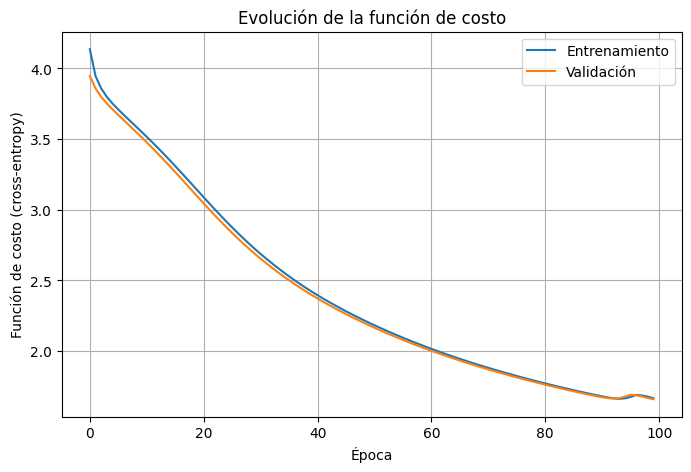

In [219]:
visual.graficar_funcion_costo(historial_M0)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
2.d) Métricas de Performance
</h3>

In [220]:
tabla_train_M0, matriz_train_M0 = metricas.evaluar_modelo(
    modelo=M0,
    X=X_tr_flat,
    y_true=y_tr,
    y_true_onehot=y_tr_onehot,
    nombre_conjunto="Train",
    num_classes=47
)

tabla_val_M0, matriz_val_M0 = metricas.evaluar_modelo(
    modelo=M0,
    X=X_val_flat,
    y_true=y_val,
    y_true_onehot=y_val_onehot,
    nombre_conjunto="Validation",
    num_classes=47
)

tabla_metricas = pd.concat([tabla_train_M0, tabla_val_M0], ignore_index=True)
tabla_metricas

,Conjunto,Accuracy,Cross-Entropy,F1 Macro
0,Train,0.577168,1.658801,0.336551
1,Validation,0.578157,1.659710,0.338070


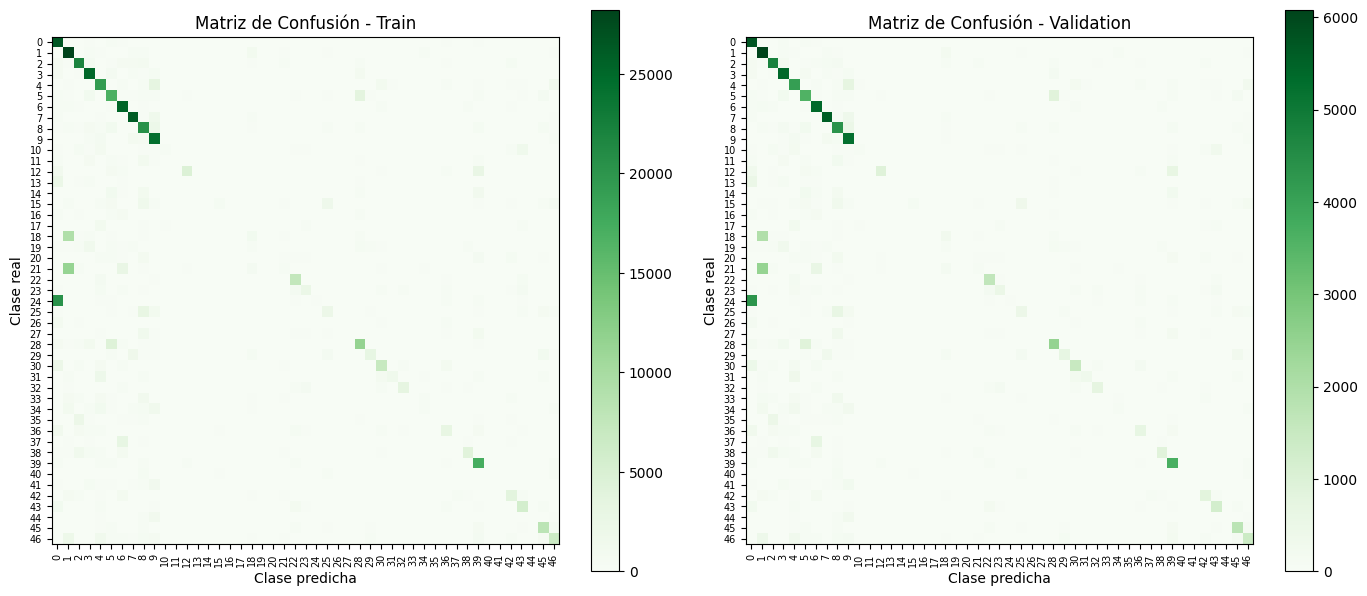

In [221]:
visual.graficar_matrices_confusion(matriz_train_M0, matriz_val_M0)

<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
3) Red Neuronal Avanzada
</h1>

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
3.a) Mejoras al Entrenamiento
</h3>

In [222]:
# modelo que se va a usar para las próximas mejoras
modelo = MLP.MLP([784, 128, 64, 47])

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Modelo M0
</div>

In [ ]:
tabla_val_M0["Modelo"] = "M0"
tabla_val_M0["Tiempo entrenamiento (seg)"] = tiempo_M0

tabla_val_M0

,Conjunto,Accuracy,Cross-Entropy,F1 Macro,Modelo,Tiempo entrenamiento (seg)
0,Validation,0.578157,1.65971,0.33807,M0,563.908015


: 

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Schedule lineal
</div>

In [ ]:
historial_lineal, tabla_lineal, matriz_lineal = utils.entrenar_y_evaluar_modelo(
    nombre="Schedule lineal",
    modelo=modelo,
    X_tr=X_tr_flat,
    y_tr_onehot=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val,
    y_val_onehot=y_val_onehot,
    parametros_fit={
        "epochs": 40,
        "learning_rate": 0.5,
        "schedule": "linear",
        "lr_final": 0.001,
        "k": 30
    }
)

tabla_lineal

In [ ]:
historial_lineal[historial_lineal["epoch"] % 5 == 0]

,epoch,learning_rate,train_loss,val_loss
0,0,0.500000,3.728285,3.729250
5,5,0.416833,2.944182,2.944549
10,10,0.333667,2.642753,2.642525
15,15,0.250500,2.338190,2.337110
20,20,0.167333,2.049289,2.049240
25,25,0.084167,1.966431,1.966640
30,30,0.001000,1.944651,1.944926
35,35,0.001000,1.944029,1.944305


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Schedule exponencial
</div>

In [ ]:
historial_exp, tabla_exp, matriz_exp = utils.entrenar_y_evaluar_modelo(
    nombre="Schedule Exponencial",
    modelo=modelo,
    X_tr=X_tr_flat,
    y_tr_onehot=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val,
    y_val_onehot=y_val_onehot,
    parametros_fit={
        "epochs": 40,
        "learning_rate": 0.1,
        "schedule": "exponential",
        "c": 0.98,
        "s": 1
    }
)

tabla_exp

,Conjunto,Accuracy,Cross-Entropy,F1 Macro,Modelo,Tiempo entrenamiento (seg)
0,Schedule Exponencial,0.577646,1.665742,0.323353,Schedule Exponencial,232.853857


In [ ]:
historial_exp[historial_exp["epoch"] % 5 == 0]

,epoch,learning_rate,train_loss,val_loss
0,0,0.100000,1.931121,1.931437
5,5,0.090392,1.875571,1.876048
10,10,0.081707,1.829011,1.829596
15,15,0.073857,1.789552,1.790229
20,20,0.066761,1.755857,1.756612
25,25,0.060346,1.726898,1.727708
30,30,0.054548,1.701880,1.702737
35,35,0.049307,1.680165,1.681058


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Mini-batch stochastic gradient descent
</div>

In [ ]:
historial_minibatch, tabla_minibatch, matriz_minibatch = utils.entrenar_y_evaluar_modelo(
    nombre="Mini-batch SGD",
    modelo=modelo,
    X_tr=X_tr_flat,
    y_tr_onehot=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val,
    y_val_onehot=y_val_onehot,
    parametros_fit={
        "epochs": 50,
        "learning_rate": 0.1,
        "batch_size": 256,
        "optimizador": "sgd"
    }
)

tabla_minibatch

,Conjunto,Accuracy,Cross-Entropy,F1 Macro,Modelo,Tiempo entrenamiento (seg)
0,Mini-batch SGD,0.87464,0.366802,0.841808,Mini-batch SGD,223.258185


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Optimizador Adam
</div>

In [ ]:
historial_adam, tabla_adam, matriz_adam = utils.entrenar_y_evaluar_modelo(
    nombre="Adam",
    modelo=modelo,
    X_tr=X_tr_flat,
    y_tr_onehot=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val,
    y_val_onehot=y_val_onehot,
    parametros_fit={
        "epochs": 50,
        "learning_rate": 0.001,
        "optimizador": "adam"
    }
)

tabla_adam

,Conjunto,Accuracy,Cross-Entropy,F1 Macro,Modelo,Tiempo entrenamiento (seg)
0,Adam,0.812725,0.665523,0.719,Adam,245.58661


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Weight decay / Regularización L2
</div>

In [ ]:
historial_l2, tabla_l2, matriz_l2 = utils.entrenar_y_evaluar_modelo(
    nombre="Regularización L2",
    modelo=modelo,
    X_tr=X_tr_flat,
    y_tr_onehot=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val,
    y_val_onehot=y_val_onehot,
    parametros_fit={
        "epochs": 50,
        "learning_rate": 0.5,
        "optimizador": "sgd",
        "l2_lambda": 1e-4
    }
)

tabla_l2

,Conjunto,Accuracy,Cross-Entropy,F1 Macro,Modelo,Tiempo entrenamiento (seg)
0,Regularización L2,0.858512,0.420439,0.810103,Regularización L2,235.376465


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Early Stopping
</div>

In [ ]:
historial_early, tabla_early, matriz_early = utils.entrenar_y_evaluar_modelo(
    nombre="Early Stopping",
    modelo=modelo,
    X_tr=X_tr_flat,
    y_tr_onehot=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val,
    y_val_onehot=y_val_onehot,
    parametros_fit={
        "epochs": 100,
        "learning_rate": 0.3,
        "optimizador": "sgd",
        "early_stopping": True,
        "patience": 10
    }
)

tabla_early

,Conjunto,Accuracy,Cross-Entropy,F1 Macro,Modelo,Tiempo entrenamiento (seg)
0,Early Stopping,0.865291,0.398425,0.821582,Early Stopping,456.227389


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Comparacion entre los modelos
</div>

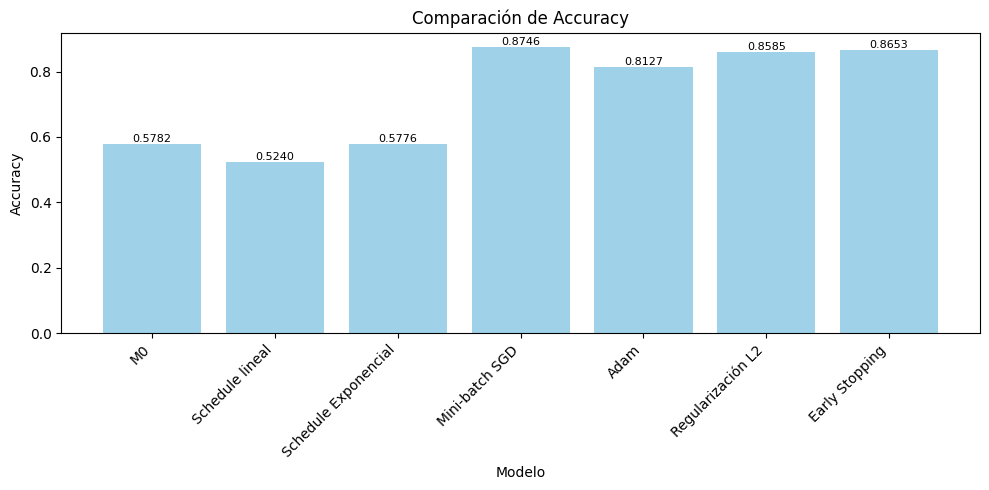

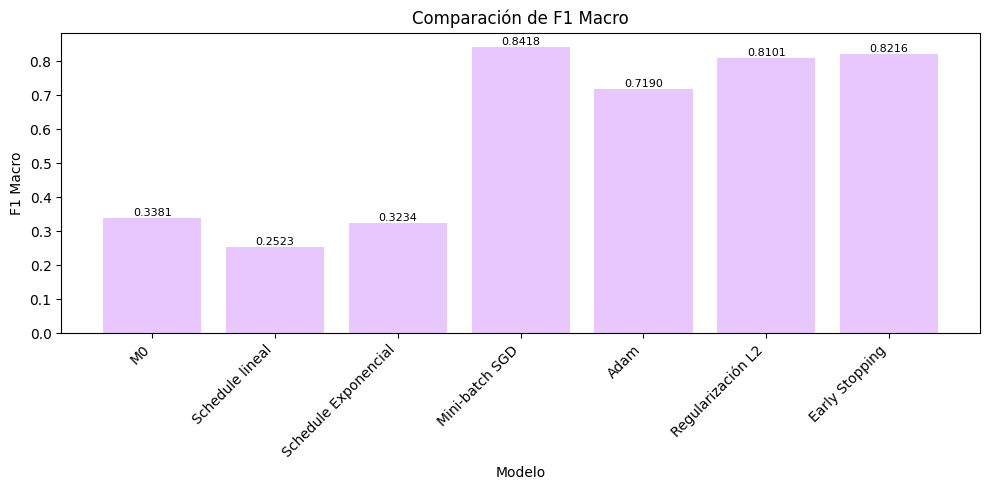

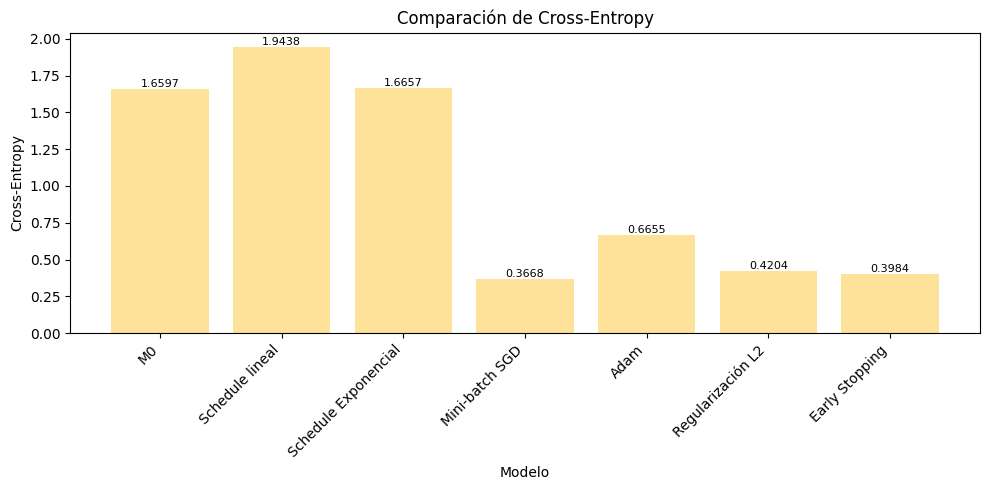

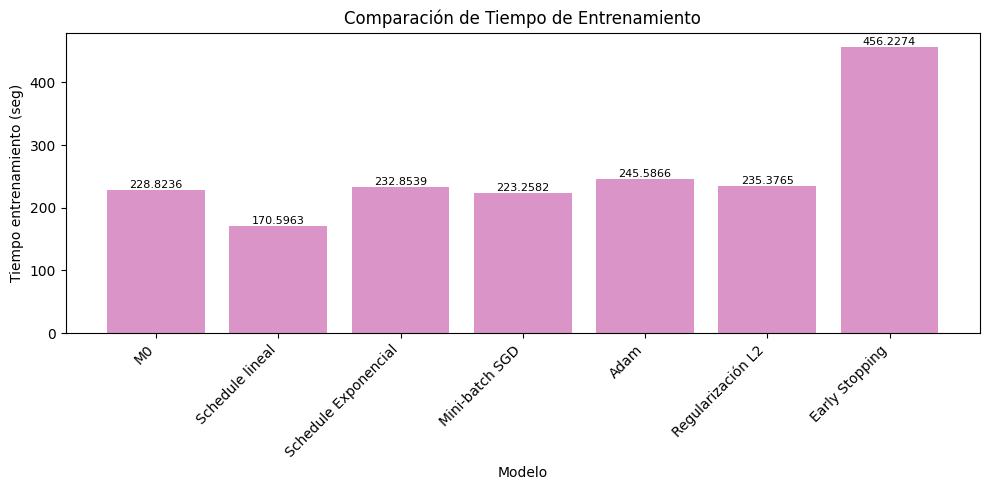

In [ ]:
tabla_comparacion = pd.concat(
    [
        tabla_val_M0,
        tabla_lineal,
        tabla_exp,
        tabla_minibatch,
        tabla_adam,
        tabla_l2,
        tabla_early
    ],
    ignore_index=True
)

visual.graficar_comparacion_modelos(tabla_comparacion)

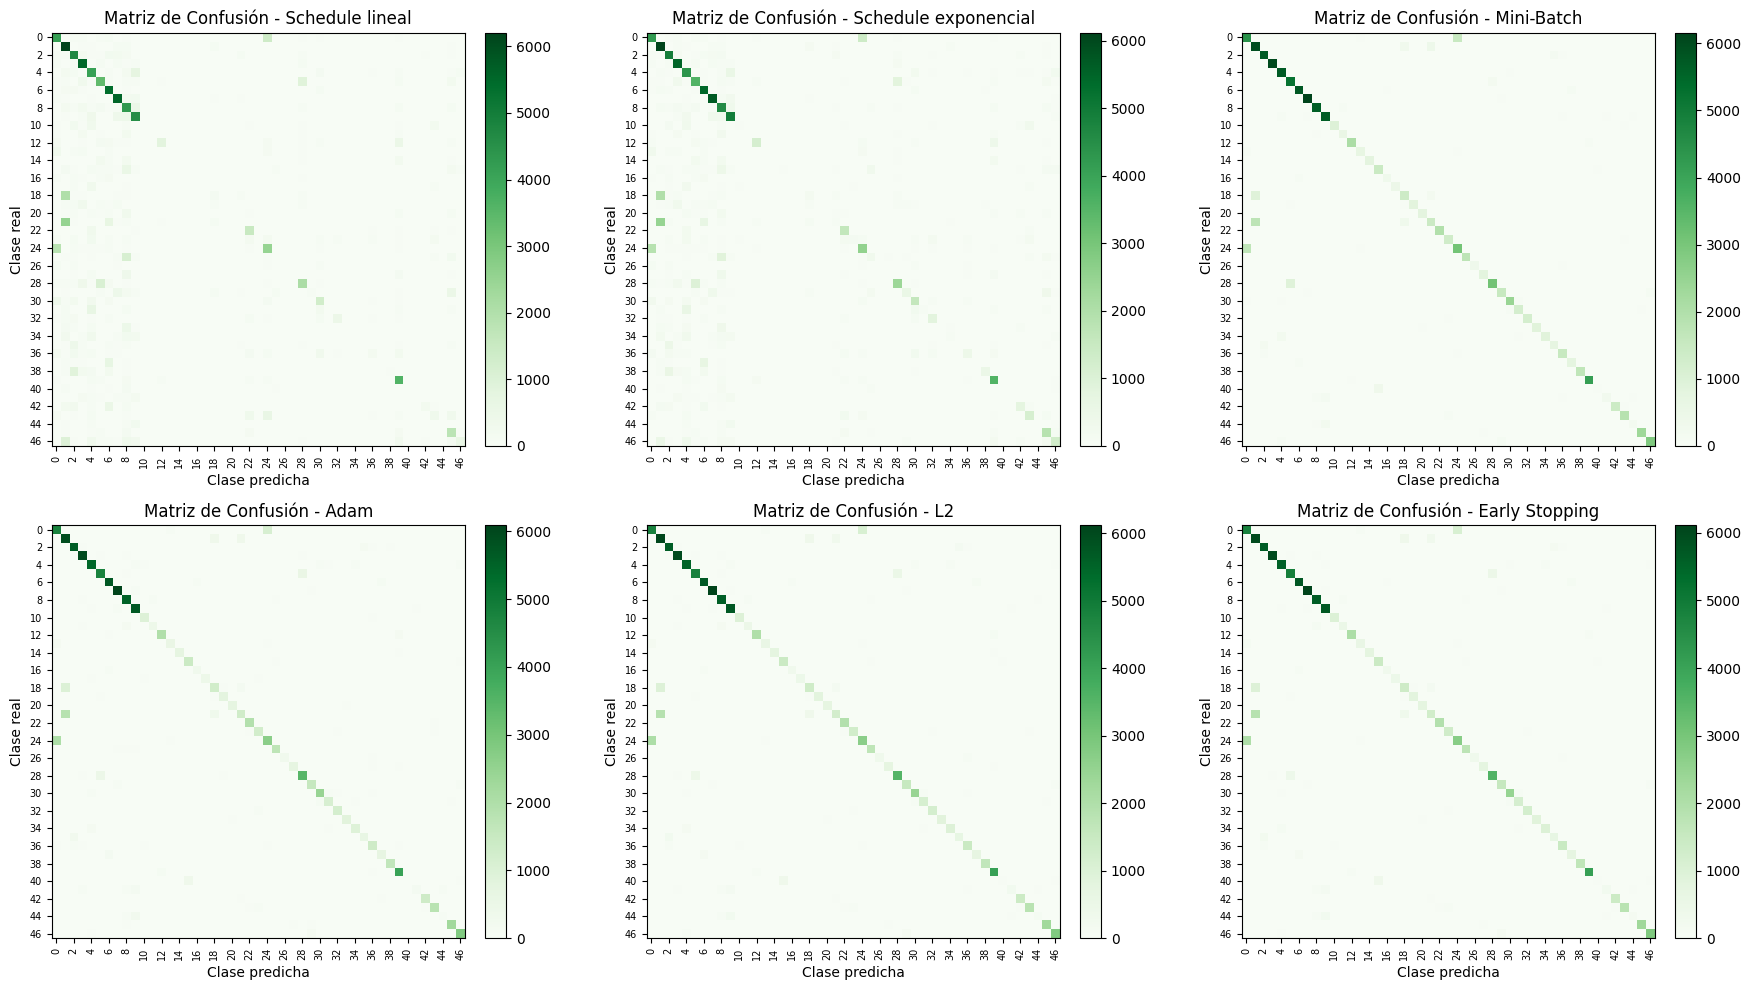

In [ ]:
matrices_modelos = [
    matriz_lineal,
    matriz_exp, 
    matriz_minibatch,
    matriz_adam,
    matriz_l2,
    matriz_early
]

nombres_modelos = [
    "Schedule lineal",
    "Schedule exponencial",
    "Mini-Batch",
    "Adam",
    "L2",
    "Early Stopping",
    "Early Stopping + Mini Batch"
]

visual.graficar_matrices_confusion_modelos(matrices_modelos, nombres_modelos)

en gral todas aicertan a las clases mayoritarias pero a las minoritarias no toodos. los que si:
- mini batch + early
- adam
- L2

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
3.b) 
</h3>

A partir de los resultados del item 3.a, se toma como punto de partida la mejora que mostró mayor impacto individual sobre M0. En este caso, se utiliza:

M0 + Mini-Batch

Luego, se realiza una búsqueda incremental:

1. Se fija Mini-Batch como parte del modelo base, porque fue una de las mejoras que más aumentó las métricas respecto de M0.

2. Se compara Mini-Batch + SGD contra Mini-Batch + Adam, manteniendo la misma arquitectura y condiciones de entrenamiento.

3. El mejor de esos dos modelos pasa a ser la nueva base de búsqueda.

4. Sobre esa base, se realiza un grid search acotado probando:
   - distintos learning rates
   - distintos batch sizes
   - distintos valores de L2
   - schedule lineal, exponencial o sin schedule
   - algunas arquitecturas alternativas

5. Se selecciona como modelo final aquel que obtenga mejor F1 Macro en validation, usando Accuracy y Cross-Entropy como métricas complementarias.

No se busca demostrar que una mejora siempre sea superior para cualquier combinación de hiperparámetros, sino encontrar una configuración empíricamente competitiva sobre el conjunto de validación. Por eso, una vez identificada una mejora prometedora, se la conserva como parte de la base y se ajustan sus hiperparámetros mediante una grilla acotada.

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Early Stopping + Mini-Batch
</div>

In [ ]:
historial_early_minibatch, tabla_early_minibatch, matriz_early_minibatch = utils.entrenar_y_evaluar_modelo(
    nombre="Early Stopping + Mini Batch",
    modelo=modelo,
    X_tr=X_tr_flat,
    y_tr_onehot=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val,
    y_val_onehot=y_val_onehot,
    parametros_fit={
        "epochs": 150,
        "learning_rate": 0.3,
        "optimizador": "sgd",
        "batch_size" : 256,
        "early_stopping": True,
        "patience": 10
    }
)

tabla_early_minibatch

Early stopping en epoch 28


,Conjunto,Accuracy,Cross-Entropy,F1 Macro,Modelo,Tiempo entrenamiento (seg)
0,Early Stopping + Mini Batch,0.874038,0.366082,0.840118,Early Stopping + Mini Batch,130.022673


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Adam + Mini-Batch
</div>

In [ ]:
historial_adam_minibatch, tabla_adam_minibatch, matriz_adam_minibatch = utils.entrenar_y_evaluar_modelo(
    nombre="Adam + Mini-Batch",
    modelo=modelo,
    X_tr=X_tr_flat,
    y_tr_onehot=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val,
    y_val_onehot=y_val_onehot,
    parametros_fit={
        "epochs": 100,
        "learning_rate": 0.001,
        "batch_size": 256,
        "optimizador": "adam"
    }
)

tabla_adam_minibatch

,Conjunto,Accuracy,Cross-Entropy,F1 Macro,Modelo,Tiempo entrenamiento (seg)
0,Adam + Mini-Batch,0.79701,0.756356,0.69201,Adam + Mini-Batch,710.973559


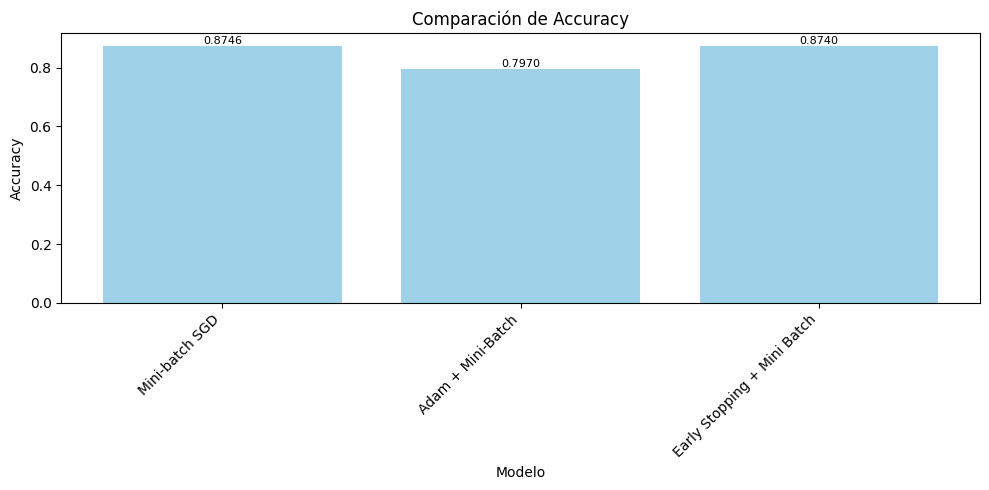

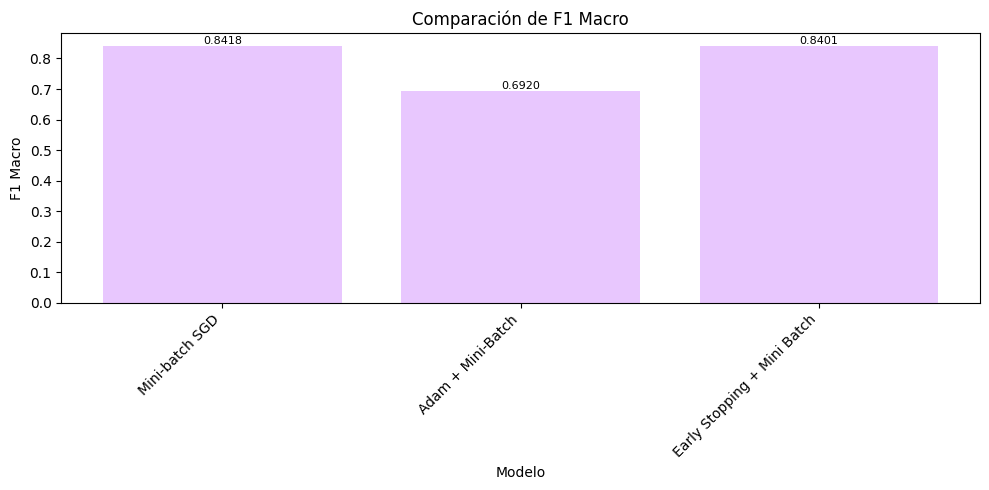

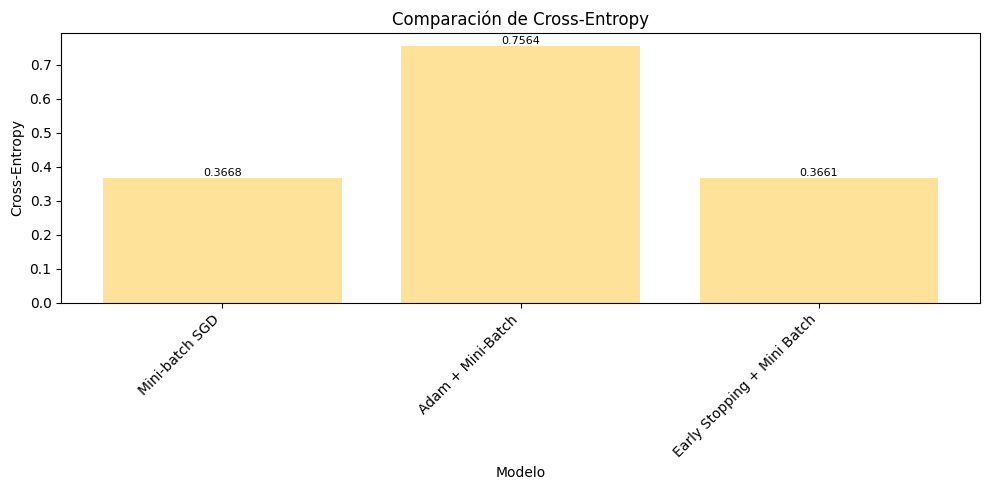

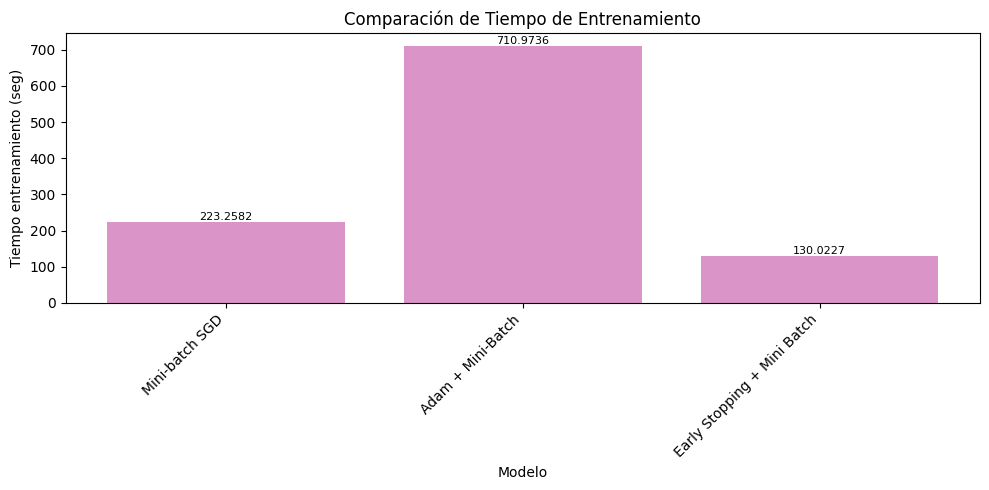

In [ ]:
tabla_comparacion = pd.concat(
    [
        tabla_minibatch,tabla_adam_minibatch,tabla_early_minibatch
    ],
    ignore_index=True
)

visual.graficar_comparacion_modelos(tabla_comparacion)

el modelo probablemente NO estaba sobreentrenando fuerte. Porque Early Stopping casi no mejora respecto de SGD.

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Hiperparametros
</div>

búsqueda ordenada de configuraciones y elegir la que tenga menor validation loss. Ese modelo elegido pasa a llamarse M1.

Como Early Stopping no produjo una mejora relevante respecto del modelo Mini-batch SGD, se interpreta que el modelo base no estaba presentando un sobreentrenamiento fuerte. Por lo tanto, para reducir el costo computacional de la búsqueda de hiperparámetros, no se incorporó Early Stopping dentro del grid principal.

en esta etapa experimental no mostró una ganancia significativa.

In [ ]:
resultado_busqueda = sgs.stage_grid_search(
    modelo_class=MLP.MLP,
    X_train=X_tr_flat,
    y_train=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val_onehot,
    input_dim=784,
    output_dim=47,
    epochs=30,
    seed=42
)

resultados_completos = resultado_busqueda["resultados_completos"]
resultados_completos.head(10)


STAGE 1: Arquitectura
Probando arquitectura 1/3: [128, 64]
Probando arquitectura 2/3: [256, 128]


KeyboardInterrupt: 

In [ ]:
mejor_config_m1 = resultado_busqueda["mejor_config_m1"]
mejor_config_m1


In [ ]:
M1 = resultado_busqueda["mejor_modelo_m1"]
historial_M1 = resultado_busqueda["mejor_history_m1"]


In [ ]:
historial_M1